In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROCESSED_DATA_PATH = Path("../data/processed/delhi_traffic_hourly.parquet")

df = pd.read_parquet(PROCESSED_DATA_PATH)

print("Shape:", df.shape)
print("Memory usage:", f"{df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Shape: (11970240, 11)
Memory usage: 2684.75 MB


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11970240 entries, 0 to 11970239
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   segment_id      int64         
 2   new_segment_id  object        
 3   speed_limit     int64         
 4   frc             int64         
 5   street_name     object        
 6   distance        float64       
 7   time_set        int64         
 8   probe_count     int64         
 9   hour            int64         
 10  timestamp       datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(6), object(2)
memory usage: 1004.6+ MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,11970240,NaN,NaN,NaN,2024-08-20 11:59:59.999983872,2024-08-11 00:00:00,2024-08-15 18:00:00,2024-08-20 12:00:00,2024-08-25 06:00:00,2024-08-30 00:00:00,NaN
segment_id,11970240.0,NaN,NaN,NaN,7338541212028.310547,-13560345653226.0,13560110870475.0,13560136836380.5,13560235452584.0,13560345653713.0,11402856150465.027344
new_segment_id,11970240,24938,-00004e30-3400-0400-0000-0000008bad86,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speed_limit,11970240.0,NaN,NaN,NaN,47.527508,18.0,45.0,50.0,50.0,80.0,8.156442
frc,11970240.0,NaN,NaN,NaN,3.609993,1.0,2.0,4.0,5.0,6.0,1.604674
street_name,10900320,465,Mahatma Gandhi Marg,504960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance,11970240.0,NaN,NaN,NaN,56.290974,3.5,15.27,34.14,70.59,1353.77,68.95495
time_set,11970240.0,NaN,NaN,NaN,13.5,2.0,7.75,13.5,19.25,25.0,6.922187
probe_count,11970240.0,NaN,NaN,NaN,124.031707,0.0,9.0,46.0,148.0,2766.0,196.264527
hour,11970240.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922187


In [5]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique roads:", df["segment_id"].nunique())

print("\nUnique dates:", df["date"].nunique())

print("\nUnique timestamps:", df["timestamp"].nunique())

Missing values:
date                    0
segment_id              0
new_segment_id          0
speed_limit             0
frc                     0
street_name       1069920
distance                0
time_set                0
probe_count             0
hour                    0
timestamp               0
dtype: int64

Duplicate rows: 0

Unique roads: 24938

Unique dates: 20

Unique timestamps: 480


In [6]:
probe_stats = df["probe_count"].describe()

print(probe_stats)

count    1.197024e+07
mean     1.240317e+02
std      1.962645e+02
min      0.000000e+00
25%      9.000000e+00
50%      4.600000e+01
75%      1.480000e+02
max      2.766000e+03
Name: probe_count, dtype: float64


In [7]:
zero_count = (df["probe_count"] == 0).sum()
non_zero_count = (df["probe_count"] > 0).sum()

print("Zero probe observations:", f"{zero_count:,}")
print("Non-zero observations:", f"{non_zero_count:,}")

print("Zero percentage:", f"{zero_count / len(df) * 100:.2f}%")
print("Non-zero percentage:", f"{non_zero_count / len(df) * 100:.2f}%")

Zero probe observations: 772,658
Non-zero observations: 11,197,582
Zero percentage: 6.45%
Non-zero percentage: 93.55%


In [8]:
percentiles = df["probe_count"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

print(percentiles)

0.500      46.0
0.750     148.0
0.900     355.0
0.950     526.0
0.990     938.0
0.999    1509.0
Name: probe_count, dtype: float64


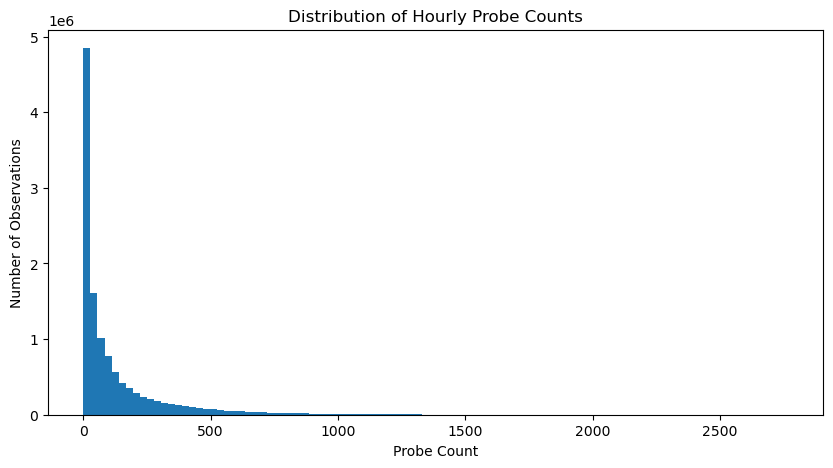

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["probe_count"],
    bins=100
)

plt.xlabel("Probe Count")
plt.ylabel("Number of Observations")
plt.title("Distribution of Hourly Probe Counts")

plt.show()

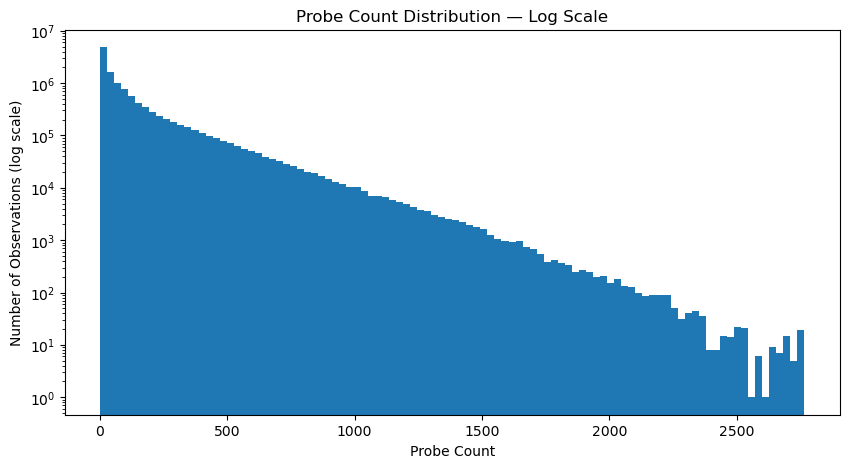

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["probe_count"],
    bins=100,
    log=True
)

plt.xlabel("Probe Count")
plt.ylabel("Number of Observations (log scale)")
plt.title("Probe Count Distribution — Log Scale")

plt.show()

In [11]:
hourly_traffic = (
    df.groupby("hour")["probe_count"]
      .agg(["mean", "median", "std"])
      .reset_index()
)

hourly_traffic

,hour,mean,median,std
0,0,74.265641,27.0,117.941276
1,1,50.590432,17.0,85.376367
2,2,35.976939,11.0,63.547687
3,3,31.984514,9.0,62.668115
4,4,37.517924,10.0,75.027083
5,5,49.734171,13.0,95.239392
6,6,62.591898,19.0,110.230305
7,7,87.300493,31.0,149.735086
8,8,124.672550,47.0,202.151524
9,9,149.245810,63.0,221.709601


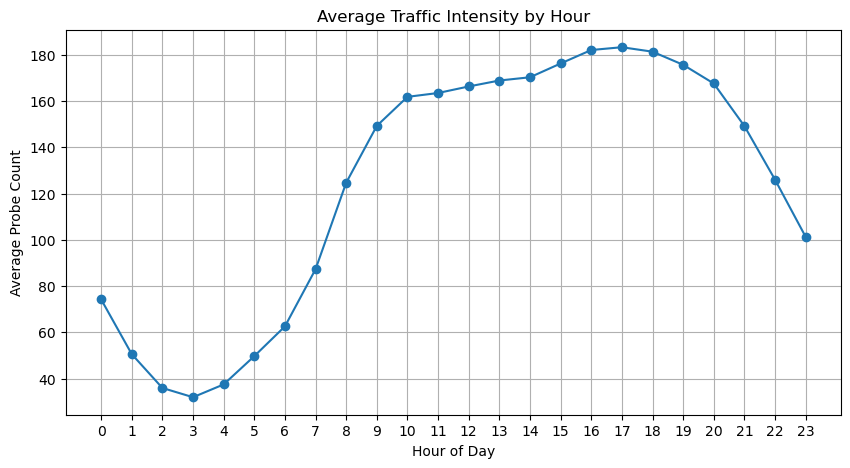

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["mean"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Probe Count")
plt.title("Average Traffic Intensity by Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()

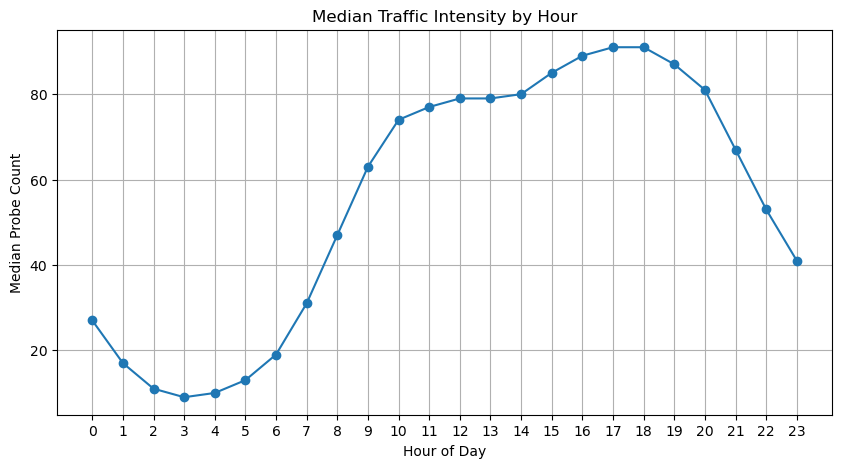

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["median"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Median Probe Count")
plt.title("Median Traffic Intensity by Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [14]:
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek >= 5

weekend_traffic = (
    df.groupby("is_weekend")["probe_count"]
      .agg(["mean", "median", "std"])
)

weekend_traffic

,mean,median,std
is_weekend,,,
False,123.837168,46.0,195.850474
True,124.615323,46.0,197.500360


In [15]:
hour_weekend = (
    df.groupby(["hour", "is_weekend"])["probe_count"]
      .mean()
      .reset_index()
)

hour_weekend

,hour,is_weekend,probe_count
0,0,False,71.682003
1,0,True,82.016553
2,1,False,48.097487
3,1,True,58.069268
4,2,False,32.804652
5,2,True,45.493801
6,3,False,29.285286
7,3,True,40.082196
8,4,False,35.812254
9,4,True,42.634935


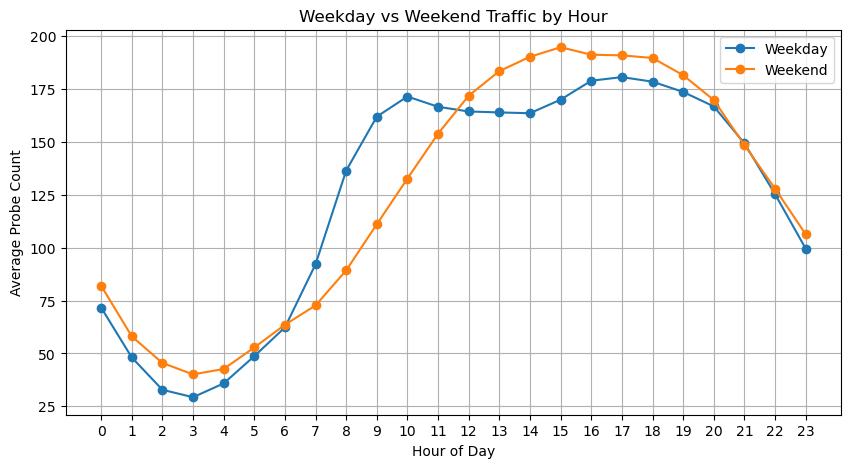

In [16]:
plt.figure(figsize=(10, 5))

for weekend_status in [False, True]:
    subset = hour_weekend[
        hour_weekend["is_weekend"] == weekend_status
    ]

    label = "Weekend" if weekend_status else "Weekday"

    plt.plot(
        subset["hour"],
        subset["probe_count"],
        marker="o",
        label=label
    )

plt.xlabel("Hour of Day")
plt.ylabel("Average Probe Count")
plt.title("Weekday vs Weekend Traffic by Hour")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

In [17]:
top_roads = (
    df.groupby(["segment_id", "street_name"])["probe_count"]
      .agg(["mean", "median", "max", "std"])
      .sort_values("mean", ascending=False)
      .head(20)
)

top_roads

,,mean,median,max,std
segment_id,street_name,,,,
-13560179880493,Swarna Jayanti Marg,1462.366667,1528.0,2527,542.795385
13560128348534,Swarna Jayanti Marg,1458.195833,1522.0,2517,540.677800
13560128348526,Swarna Jayanti Marg,1457.035417,1520.0,2516,540.286676
-13560135311099,Swarna Jayanti Marg,1454.491667,1521.0,2510,539.157446
-13560330998374,Swarna Jayanti Marg,1452.754167,1519.5,2511,538.223574
-13560330997827,Swarna Jayanti Marg,1452.254167,1521.0,2509,537.969586
-13560135311090,Swarna Jayanti Marg,1452.008333,1519.0,2511,537.868048
-13560135311098,Swarna Jayanti Marg,1444.802083,1512.0,2494,534.773618
13560344590551,Swarna Jayanti Marg,1196.454167,1324.5,2244,513.086926


In [18]:
print("Unique FRC values:")
print(sorted(df["frc"].dropna().unique()))

print("\nFRC counts:")
print(df["frc"].value_counts().sort_index())

Unique FRC values:
[1, 2, 3, 4, 5, 6]

FRC counts:
frc
1    1190400
2    2310240
3    2196000
4    2941440
5     945120
6    2387040
Name: count, dtype: int64


In [19]:
frc_traffic = (
    df.groupby("frc")["probe_count"]
      .agg(["count", "mean", "median", "std", "max"])
      .sort_index()
)

frc_traffic

,count,mean,median,std,max
frc,,,,,
1,1190400,415.606605,333.0,347.149411,2766
2,2310240,186.101426,117.0,194.044146,1867
3,2196000,125.549995,78.0,137.754090,1260
4,2941440,54.704544,27.0,69.688130,894
5,945120,41.850059,17.0,63.980730,927
6,2387040,35.123408,7.0,94.510336,1300


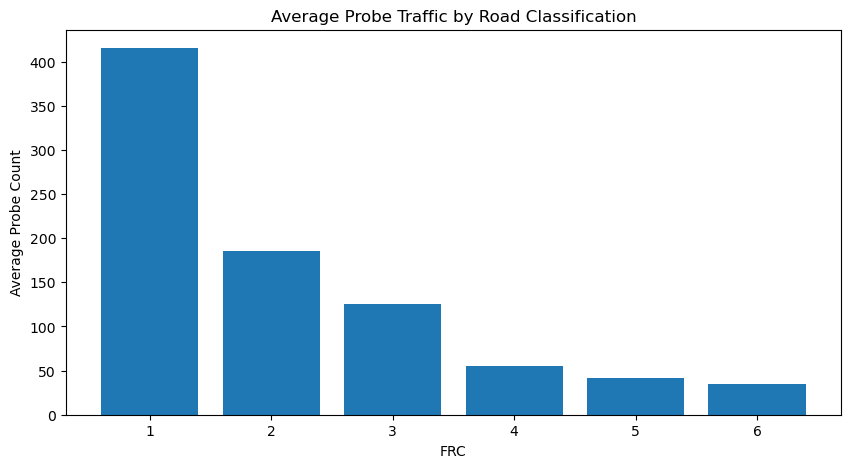

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    frc_traffic.index.astype(str),
    frc_traffic["mean"]
)

plt.xlabel("FRC")
plt.ylabel("Average Probe Count")
plt.title("Average Probe Traffic by Road Classification")

plt.show()

In [21]:
speed_traffic = (
    df.groupby("speed_limit")["probe_count"]
      .agg(["count", "mean", "median", "std"])
      .sort_index()
)

speed_traffic

,count,mean,median,std
speed_limit,,,,
18,196320,63.703673,10.0,110.960965
19,18720,104.557906,42.0,142.224646
20,48000,170.688708,88.0,193.786753
21,18240,139.960910,69.0,168.161152
22,15360,111.853581,42.0,151.822033
23,24480,119.504453,44.0,162.210487
24,18240,119.546546,50.0,151.689916
25,72960,59.957525,10.0,120.709357
26,17280,102.473843,45.0,135.853455


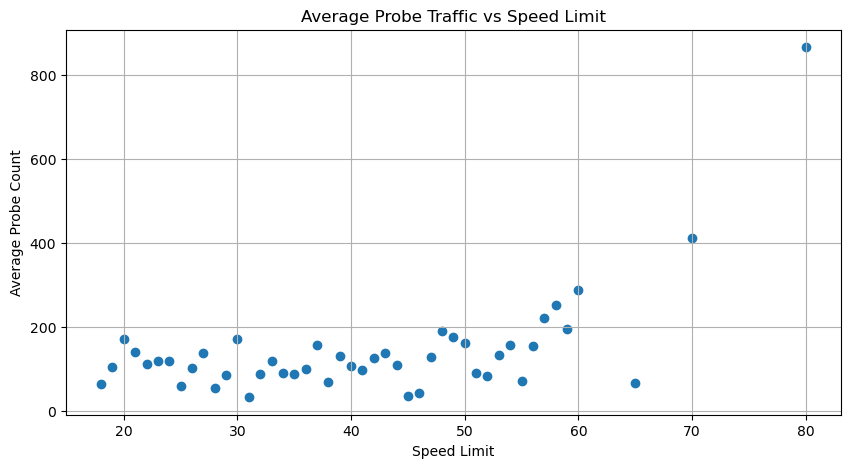

In [22]:
plt.figure(figsize=(10, 5))

plt.scatter(
    speed_traffic.index,
    speed_traffic["mean"]
)

plt.xlabel("Speed Limit")
plt.ylabel("Average Probe Count")
plt.title("Average Probe Traffic vs Speed Limit")
plt.grid(True)

plt.show()

In [23]:
distance_stats = df["distance"].describe()

distance_stats

count    1.197024e+07
mean     5.629097e+01
std      6.895495e+01
min      3.500000e+00
25%      1.527000e+01
50%      3.414000e+01
75%      7.059000e+01
max      1.353770e+03
Name: distance, dtype: float64

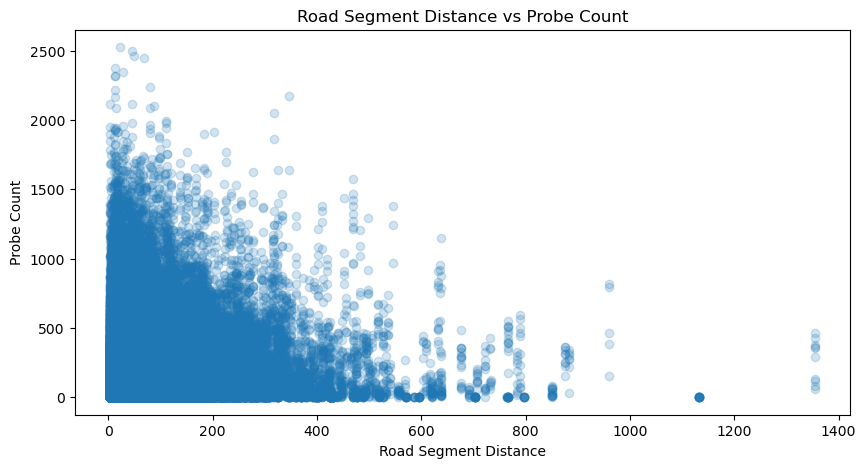

In [25]:
sample = df.sample(200000, random_state=42)

plt.figure(figsize=(10, 5))

plt.scatter(
    sample["distance"],
    sample["probe_count"],
    alpha=0.2
)

plt.xlabel("Road Segment Distance")
plt.ylabel("Probe Count")
plt.title("Road Segment Distance vs Probe Count")

plt.show()

In [26]:
df_sorted = df.sort_values(["segment_id", "timestamp"]).copy()

df_sorted["probe_lag_1"] = (
    df_sorted.groupby("segment_id")["probe_count"]
    .shift(1)
)

df_sorted[["segment_id", "timestamp", "probe_count", "probe_lag_1"]].head(30)

,segment_id,timestamp,probe_count,probe_lag_1
101232,-13560345653226,2024-08-11 00:00:00,0,NaN
101233,-13560345653226,2024-08-11 01:00:00,1,0.0
101234,-13560345653226,2024-08-11 02:00:00,0,1.0
101235,-13560345653226,2024-08-11 03:00:00,0,0.0
101236,-13560345653226,2024-08-11 04:00:00,0,0.0
101237,-13560345653226,2024-08-11 05:00:00,0,0.0
101238,-13560345653226,2024-08-11 06:00:00,0,0.0
101239,-13560345653226,2024-08-11 07:00:00,0,0.0
101240,-13560345653226,2024-08-11 08:00:00,0,0.0
101241,-13560345653226,2024-08-11 09:00:00,0,0.0


In [28]:
road_lag_corr = (
    df_sorted.groupby("segment_id")
    .apply(
        lambda x: x["probe_count"].corr(x["probe_lag_1"])
    )
    .dropna()
)

print("Number of roads:", len(road_lag_corr))
print("\nMean lag-1 correlation:", road_lag_corr.mean())
print("Median lag-1 correlation:", road_lag_corr.median())
print("25th percentile:", road_lag_corr.quantile(0.25))
print("75th percentile:", road_lag_corr.quantile(0.75))

/opt/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Number of roads: 24753

Mean lag-1 correlation: 0.7789596315048853
Median lag-1 correlation: 0.8497621360995924
25th percentile: 0.7527171158967875
75th percentile: 0.8918809297205068


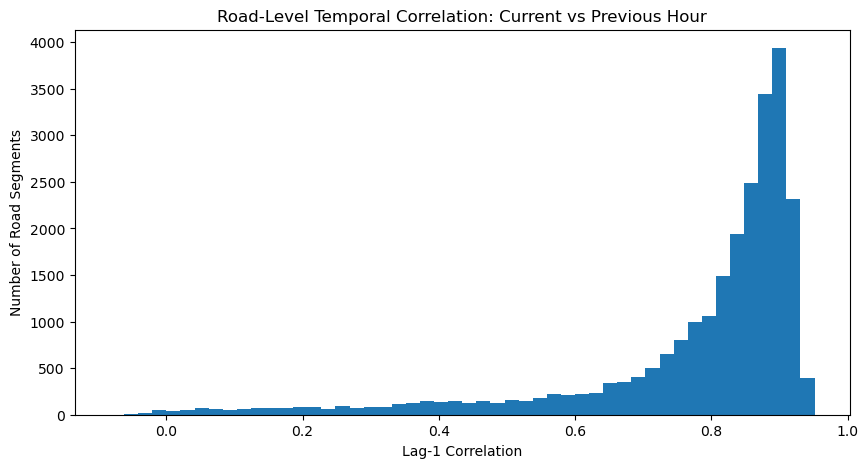

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(
    road_lag_corr,
    bins=50
)

plt.xlabel("Lag-1 Correlation")
plt.ylabel("Number of Road Segments")
plt.title("Road-Level Temporal Correlation: Current vs Previous Hour")

plt.show()

In [30]:
total_roads = df_sorted["segment_id"].nunique()
valid_correlations = road_lag_corr.notna().sum()
constant_or_invalid = total_roads - valid_correlations

print("Total road segments:", total_roads)
print("Valid lag correlations:", valid_correlations)
print("Invalid/undefined correlations:", constant_or_invalid)
print(
    "Percentage with valid correlation:",
    f"{valid_correlations / total_roads * 100:.2f}%"
)

Total road segments: 24938
Valid lag correlations: 24753
Invalid/undefined correlations: 185
Percentage with valid correlation: 99.26%


In [31]:
road_variability = (
    df.groupby("segment_id")["probe_count"]
      .agg(["mean", "std", "min", "max"])
)

road_variability["cv"] = (
    road_variability["std"] /
    road_variability["mean"].replace(0, pd.NA)
)

road_variability.describe()

,mean,std,min,max
count,24938.000000,24938.000000,24938.000000,24938.000000
mean,124.031707,67.165985,12.696407,300.951640
std,166.444446,79.553036,26.815965,339.975066
min,0.000000,0.000000,0.000000,0.000000
25%,17.212500,11.911117,0.000000,66.000000
50%,59.155208,38.038208,1.000000,182.000000
75%,163.203125,92.333652,13.000000,407.000000
max,1462.366667,598.675236,288.000000,2766.000000


In [32]:
print("Most variable road segments:")

road_variability.sort_values(
    "cv",
    ascending=False
).head(20)

Most variable road segments:


,mean,std,min,max,cv
segment_id,,,,,
-13560131369655,0.004167,0.064482,0,1,15.475754
13560138720283,0.004167,0.064482,0,1,15.475754
-13560131369663,0.004167,0.064482,0,1,15.475754
-13560332648426,0.006250,0.078892,0,1,12.622676
13560132941482,0.006250,0.078892,0,1,12.622676
-13560158355858,0.008333,0.091001,0,1,10.920093
-13560119851974,0.008333,0.091001,0,1,10.920093
-13560188886310,0.008333,0.091001,0,1,10.920093
-13560111063845,0.008333,0.091001,0,1,10.920093


In [33]:
meaningful_roads = road_variability[
    road_variability["mean"] >= 10
].copy()

print("Roads with mean probe count >= 10:")
print(len(meaningful_roads))

print("\nCV statistics:")
print(meaningful_roads["cv"].describe())

Roads with mean probe count >= 10:
20306

CV statistics:
count     20306.000000
unique    20306.000000
top           2.024267
freq          1.000000
Name: cv, dtype: float64


In [34]:
meaningful_roads.sort_values(
    "cv",
    ascending=False
).head(20)

,mean,std,min,max,cv
segment_id,,,,,
-13560119175413,18.662500,47.102015,0,329,2.523886
-13560132571839,18.852083,47.249272,0,336,2.506316
-13560233250897,18.931250,47.430924,0,333,2.50543
-13560121950893,18.935417,46.719592,0,331,2.467313
-13560129383191,10.843750,22.653111,0,106,2.089048
-13560345653148,10.225000,20.698134,0,166,2.024267
-13560341466699,10.254167,20.699006,0,166,2.018595
-13560345652719,10.266667,20.717297,0,166,2.017919
13560124720816,10.339583,20.299102,0,154,1.963242
